# Plot model fit

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from devreact import figures
from devreact import model

model_name = 'neural-dual-v7'

signal_names = ['vlpfc', 'prec', 'ang', 'lpc', 'hpc', 'phc']
roi_names = ['VLPFC', 'Precuneus', 'Angular gyrus', 'IPS/SPL', 'Hippocampus', 'PHC']

fig_dir = Path(os.environ['REMIND_FIGURES']) / 'model' / model_name
fig_dir.mkdir(parents=True, exist_ok=True)

%matplotlib inline
figures.set_style()

/Users/morton/PycharmProjects/devreact/.venv/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
pp = az.from_netcdf(fig_dir / 'posterior_predictive.nc')
max_time = 8

## Examine posterior predictive samples

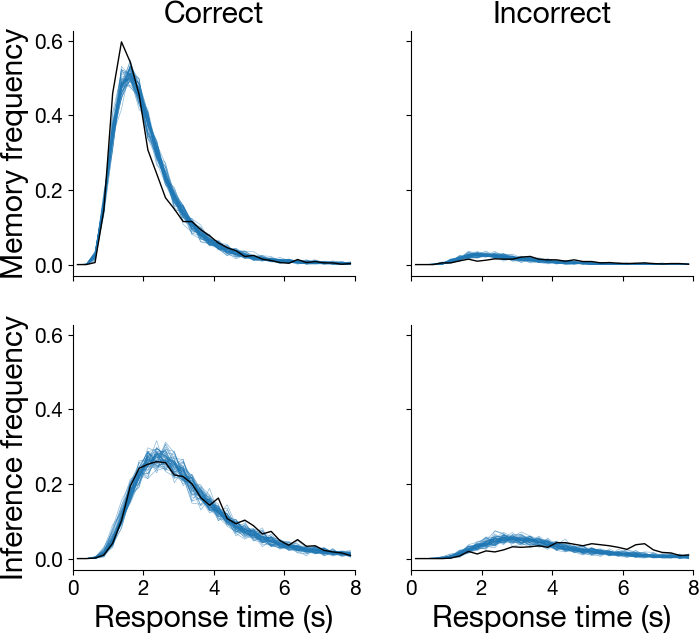

In [3]:
fig, ax = figures.plot_predictive(pp, group='posterior', max_time=max_time)
figures.savefig(fig, fig_dir / 'predictive_rt_dist.pdf')

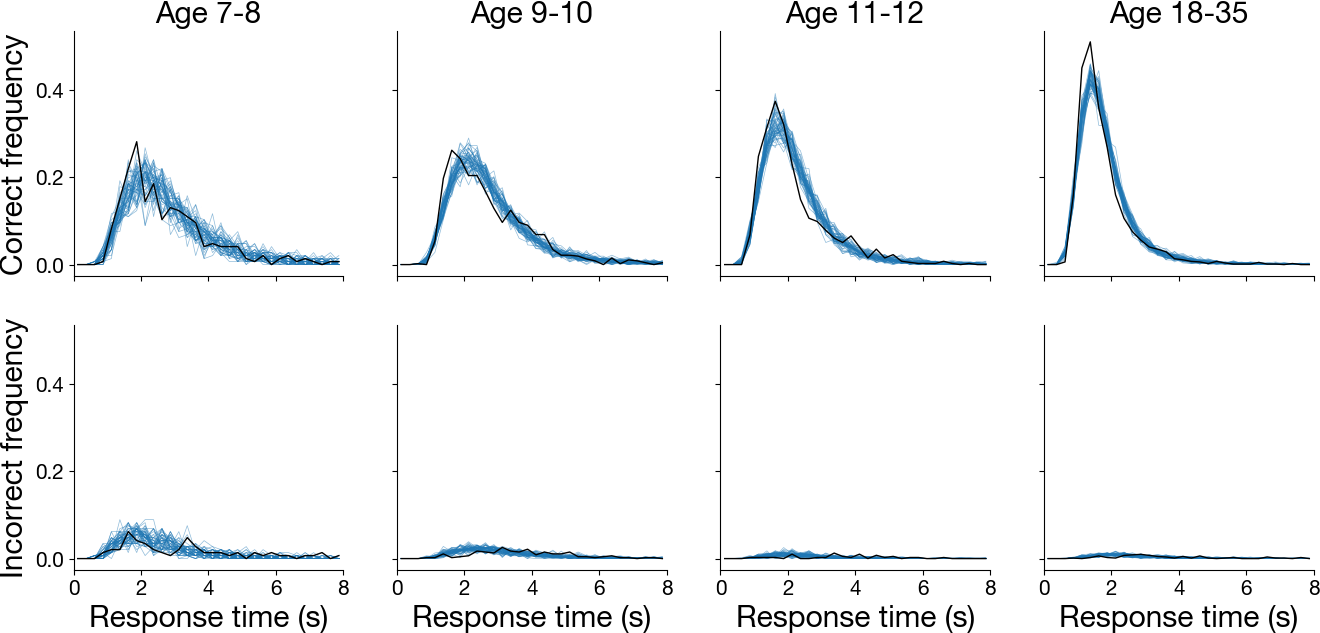

In [4]:
fig, ax = figures.plot_predictive(
    pp, 
    group='posterior', 
    max_time=max_time, 
    row='accuracy', 
    col='age', 
    trial_type='direct',
)
figures.savefig(fig, fig_dir / 'predictive_rt_dist_direct.pdf')

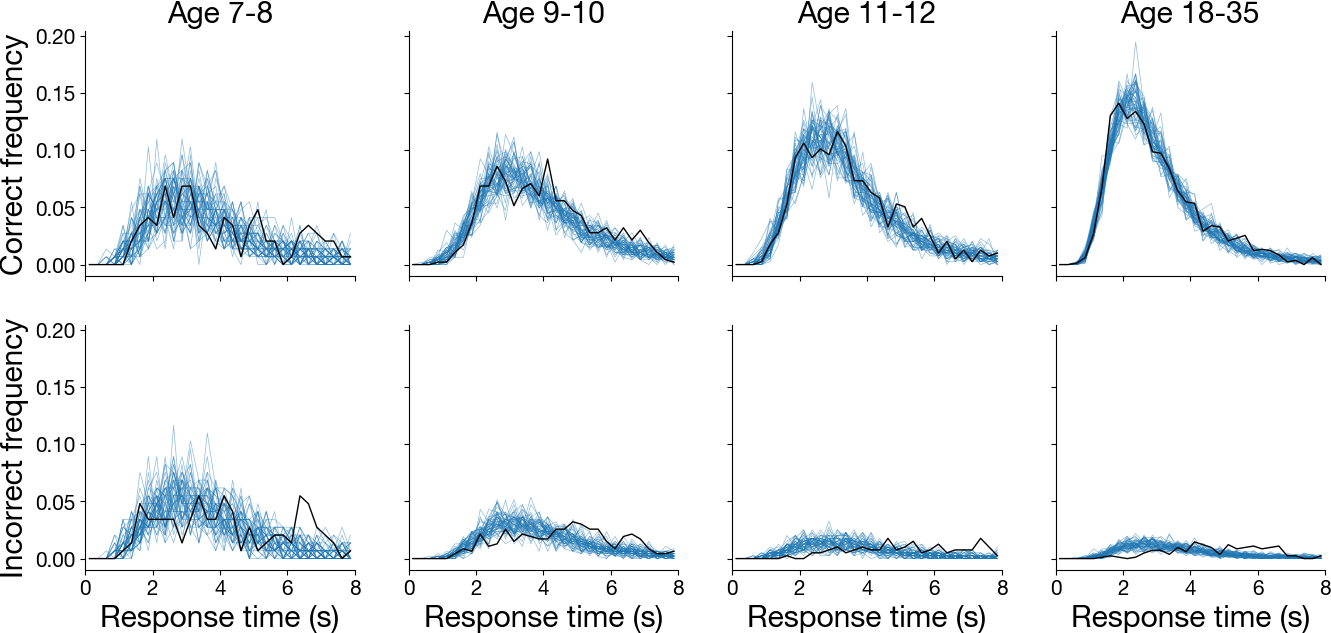

In [5]:
fig, ax = figures.plot_predictive(
    pp, 
    group='posterior', 
    max_time=max_time, 
    row='accuracy', 
    col='age', 
    trial_type='inference',
)
figures.savefig(fig, fig_dir / 'predictive_rt_dist_inference.pdf')

In [6]:
rt = model.response_time_trial(pp, max_time=max_time)
rt['trial_type'] = rt['trial_type'].map({'Direct': 'Memory', 'Indirect': 'Inference'})

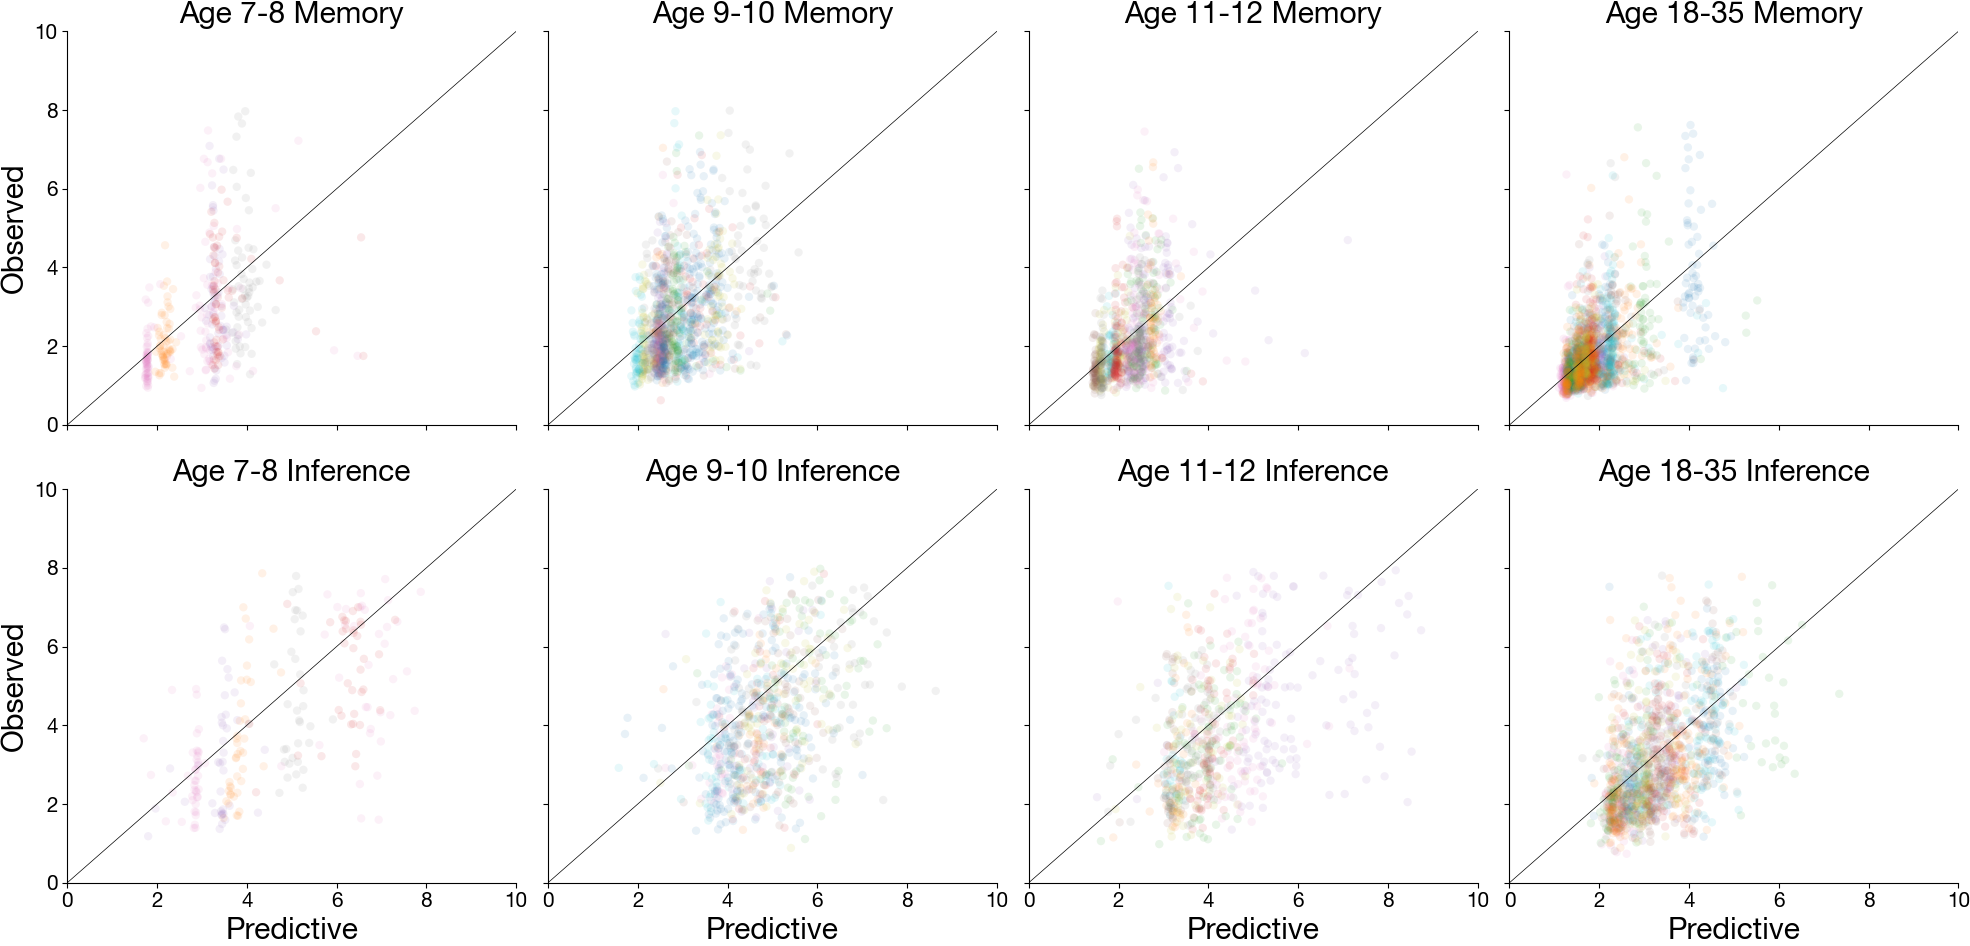

In [7]:
g = sns.relplot(
    data=rt, 
    x='Predictive', 
    y='Observed', 
    row='trial_type', 
    col='age_bin', 
    hue='subject',
    palette='tab10',
    alpha=.1, 
    linewidth=0,
    legend=False,
)
g.set_titles(template='{col_name} {row_name}')
ticks = np.arange(0, 10.5, 2)
g.set(xlim=(0, 10), ylim=(0, 10), xticks=ticks, yticks=ticks);
for ax in g.axes.ravel():
    ax.plot([0, 10], [0, 10], '-k', linewidth=0.5)

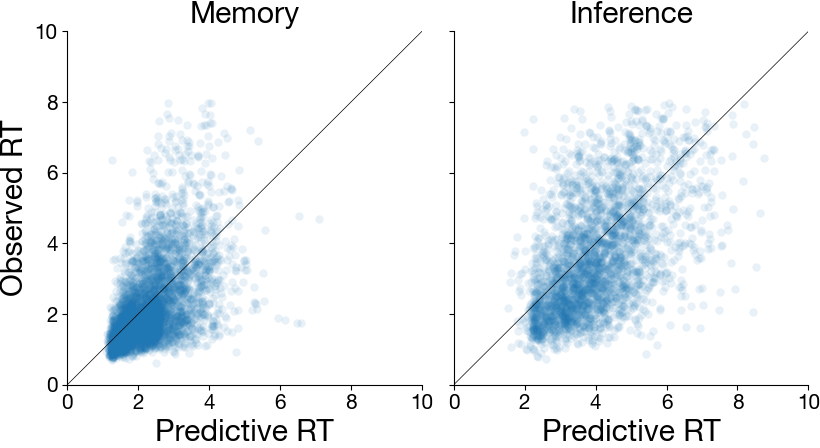

In [8]:
g = sns.relplot(
    data=rt, 
    x='Predictive', 
    y='Observed', 
    col='trial_type', 
    alpha=.1, 
    linewidth=0, 
    aspect=.85,
)
ticks = np.arange(0, 10.5, 2)
g.set(
    xlim=(0, 10), 
    ylim=(0, 10), 
    xticks=ticks, 
    yticks=ticks, 
    ylabel='Observed RT', 
    xlabel='Predictive RT',
)
g.set_titles(template='{col_name}')
for ax in g.axes.ravel():
    ax.plot([0, 10], [0, 10], '-k', linewidth=0.5)
figures.savefig(g, fig_dir / 'predictive_rt_trial.pdf')

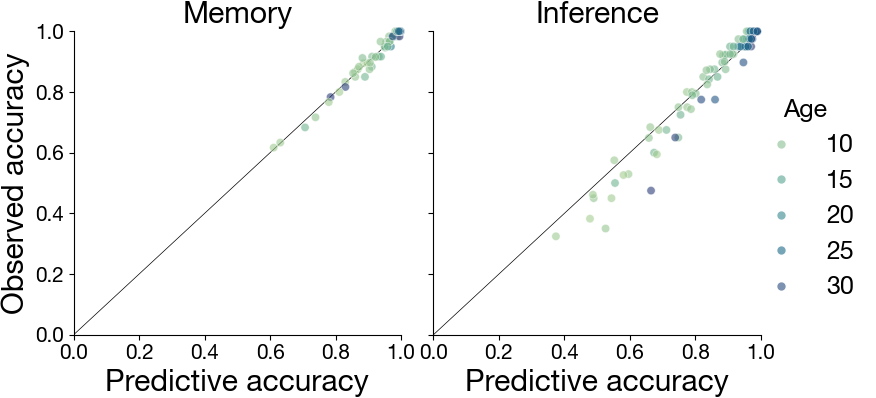

In [9]:
g = figures.plot_predictive_acc(pp)
figures.savefig(g, fig_dir / 'predictive_accuracy.pdf')

/Users/morton/PycharmProjects/devreact/src/devreact/model.py:559: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'trial' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  pps.response.assign_coords(trial=mi)


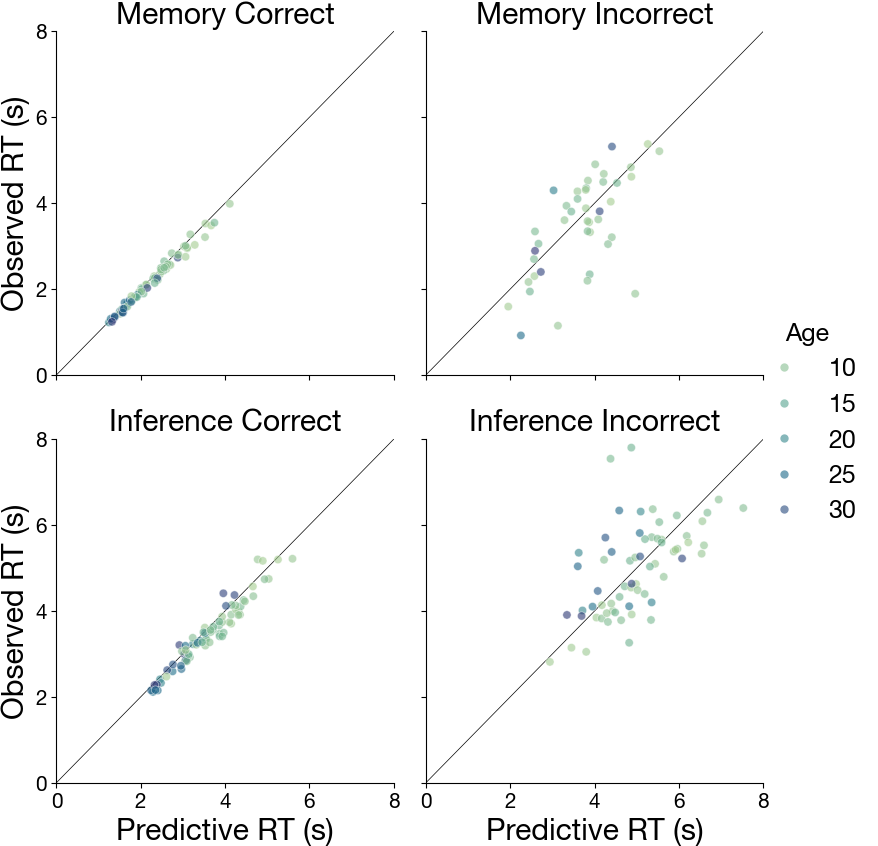

In [10]:
g = figures.plot_predictive_rt(pp, max_time=max_time)
figures.savefig(g, fig_dir / 'predictive_rt.pdf')

In [11]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.13.6
IPython version      : 9.12.0

arviz     : 0.23.4
devreact  : 0.1.0
matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 3.0.2
seaborn   : 0.13.2

